In [81]:
# Importing libraries

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [82]:
# Generating Random Data

X0 = np.random.rand(50,2)
X1 = 2 + np.random.rand(50,2)
X2 = 1 + np.random.rand(50,2)
X3 = 3 + np.random.rand(50,2)

# Concatenate the arrays vertically
Z = np.concatenate((X0, X1, X2, X3))

# Convert to a Pandas DataFrame
Z = pd.DataFrame(Z)
print("New dataset 'Z' with four overlapping clusters generated successfully.")
print(Z.head())
print(Z.tail())

New dataset 'Z' with four overlapping clusters generated successfully.
          0         1
0  0.161904  0.243993
1  0.058189  0.088646
2  0.047140  0.695556
3  0.952846  0.085304
4  0.470860  0.599879
            0         1
195  3.589856  3.545244
196  3.998325  3.570399
197  3.176698  3.328112
198  3.312230  3.388938
199  3.011868  3.951792


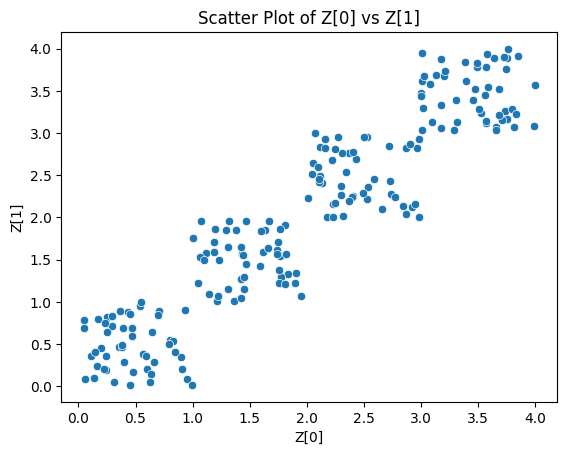

In [83]:
# Plotting Data Points
sns.scatterplot(x=Z[0], y=Z[1])
plt.xlabel('Z[0]')
plt.ylabel('Z[1]')
plt.title('Scatter Plot of Z[0] vs Z[1]')
plt.show()

Silhouette Score(n=2): 0.5440616712169374


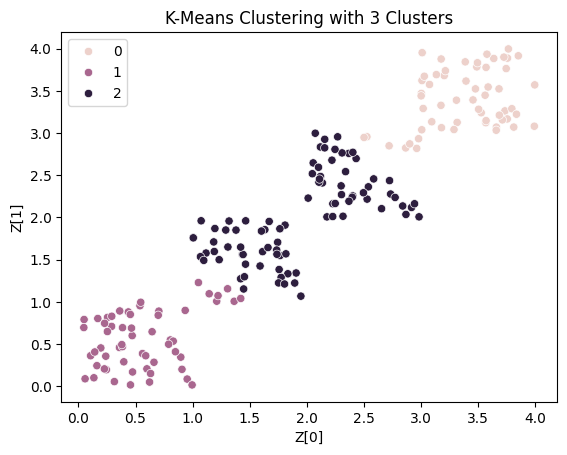

In [84]:
# KMeans Clustering and Silhouette Score

KMean = KMeans(n_clusters=3)
KMean.fit(Z)
label = KMean.predict(Z)

print(f"Silhouette Score(n=2): {silhouette_score(Z,label)}")

sns.scatterplot(x=Z[0], y=Z[1], hue = label)
plt.xlabel('Z[0]')
plt.ylabel('Z[1]')
plt.title('K-Means Clustering with 3 Clusters')
plt.show()

Hierarchical clustering performed with single linkage.


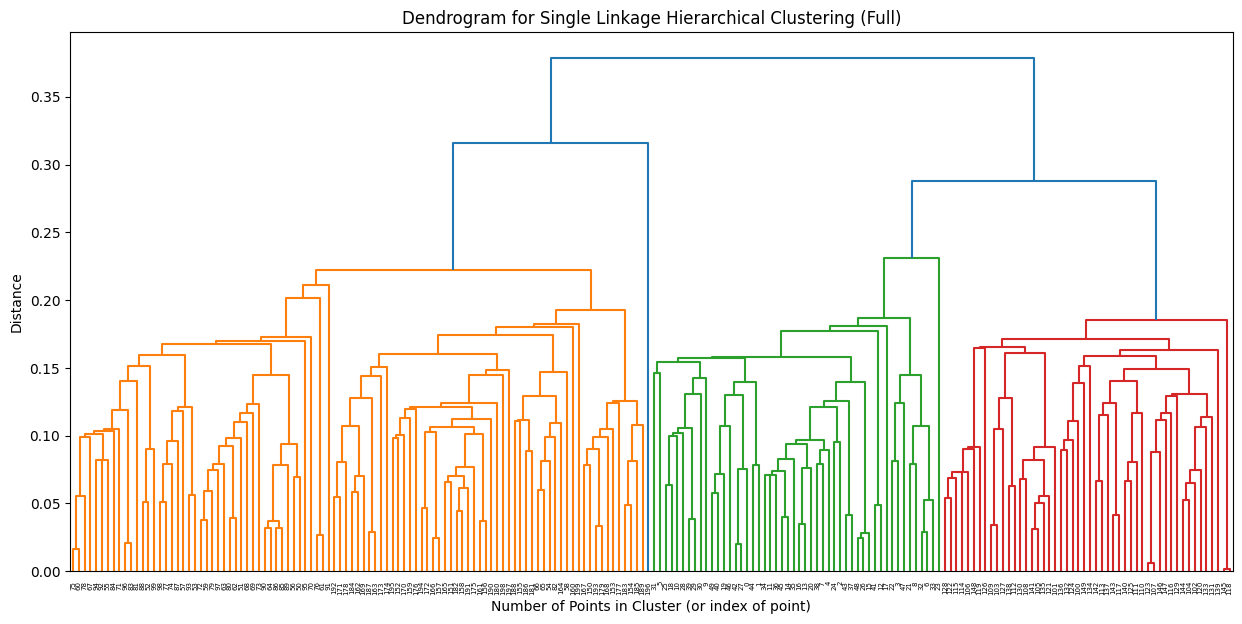

Silhouette Score for Hierarchical Clustering (3 clusters): 0.331356081536613


In [85]:
linked = linkage(Z, method='single')
print("Hierarchical clustering performed with single linkage.")

# Plot Dendogram

plt.figure(figsize=(15, 7))
dendrogram(
    linked,
    orientation='top',
    show_leaf_counts=True,
    distance_sort='descending'
)
plt.title('Dendrogram for Single Linkage Hierarchical Clustering (Full)')
plt.xlabel('Number of Points in Cluster (or index of point)')
plt.ylabel('Distance')
plt.show()

hierarchical_labels = fcluster(linked, 3, criterion='maxclust')
silhouette_hierarchical = silhouette_score(Z, hierarchical_labels)

print(f"Silhouette Score for Hierarchical Clustering (3 clusters): {silhouette_hierarchical}")